In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5190, 13)


In [3]:
print("First 5 rows:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

First 5 rows:


,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no



Dataset Shape:
(5190, 13)

Column Names:
['Unnamed: 0', 'visits', 'gender', 'age', 'income', 'illness', 'reduced', 'health', 'private', 'freepoor', 'freerepat', 'nchronic', 'lchronic']


In [4]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Data Types:
Unnamed: 0      int64
visits          int64
gender            str
age           float64
income        float64
illness         int64
reduced         int64
health          int64
private           str
freepoor          str
freerepat         str
nchronic          str
lchronic          str
dtype: object

Missing Values:
Unnamed: 0    0
visits        0
gender        0
age           0
income        0
illness       0
reduced       0
health        0
private       0
freepoor      0
freerepat     0
nchronic      0
lchronic      0
dtype: int64


In [5]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,Unnamed: 0,visits,age,income,illness,reduced,health
count,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000,5190.000000
mean,2595.500000,0.301734,0.406385,0.583160,1.431985,0.861850,1.217534
std,1498.368279,0.798134,0.204782,0.368907,1.384152,2.887628,2.124266
min,1.000000,0.000000,0.190000,0.000000,0.000000,0.000000,0.000000
25%,1298.250000,0.000000,0.220000,0.250000,0.000000,0.000000,0.000000
50%,2595.500000,0.000000,0.320000,0.550000,1.000000,0.000000,0.000000
75%,3892.750000,0.000000,0.620000,0.900000,2.000000,0.000000,2.000000
max,5190.000000,9.000000,0.720000,1.500000,5.000000,14.000000,12.000000


In [6]:
print("Gender values:")
print(df["gender"].value_counts())

print("\nPrivate Healthcare values:")
print(df["private"].value_counts())

print("\nFree Healthcare values:")
print(df["freepoor"].value_counts())

print("\nRepatriation Healthcare values:")
print(df["freerepat"].value_counts())

print("\nChronic Condition values:")
print(df["nchronic"].value_counts())

print("\nLong-term Chronic Condition values:")
print(df["lchronic"].value_counts())

Gender values:
gender
female    2702
male      2488
Name: count, dtype: int64

Private Healthcare values:
private
no     2892
yes    2298
Name: count, dtype: int64

Free Healthcare values:
freepoor
no     4968
yes     222
Name: count, dtype: int64

Repatriation Healthcare values:
freerepat
no     4099
yes    1091
Name: count, dtype: int64

Chronic Condition values:
nchronic
no     3098
yes    2092
Name: count, dtype: int64

Long-term Chronic Condition values:
lchronic
no     4585
yes     605
Name: count, dtype: int64


In [7]:
# Remove the record ID column (not a health measurement)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

print("Shape after cleaning:", df.shape)
print("Duplicate rows:", df.duplicated().sum(), "(keeping them - different people can share the same values)")

print("\nAverage visits:", round(df["visits"].mean(), 3))
print("Median visits:", df["visits"].median())
print("Max visits:", df["visits"].max())

print("\nVisit counts:")
print(df["visits"].value_counts().sort_index())

print("\nVisit percentage:")
print((df["visits"].value_counts(normalize=True).sort_index() * 100).round(2))

Shape after cleaning: (5190, 12)
Duplicate rows: 1320 (keeping them - different people can share the same values)

Average visits: 0.302
Median visits: 0.0
Max visits: 9

Visit counts:
visits
0    4141
1     782
2     174
3      30
4      24
5       9
6      12
7      12
8       5
9       1
Name: count, dtype: int64

Visit percentage:
visits
0    79.79
1    15.07
2     3.35
3     0.58
4     0.46
5     0.17
6     0.23
7     0.23
8     0.10
9     0.02
Name: proportion, dtype: float64


        count   mean  median
gender                      
female   2702  0.362     0.0
male     2488  0.236     0.0

% with at least 1 visit:
gender
female    24.43
male      15.64
Name: visited, dtype: float64


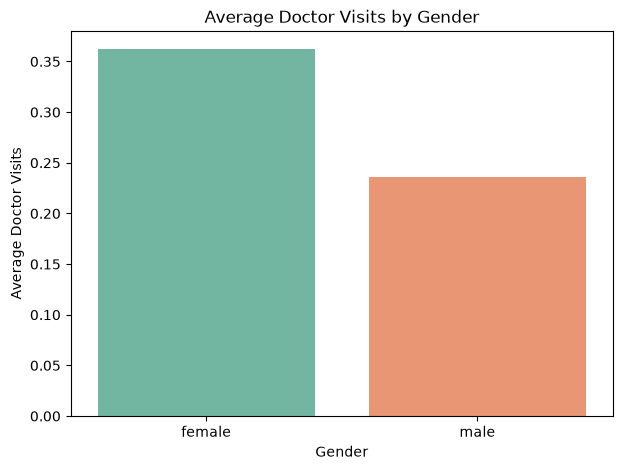

In [8]:
gender_visits = df.groupby("gender")["visits"].agg(["count", "mean", "median"]).round(3)
print(gender_visits)

# Percentage of people with at least one visit, by gender
print("\n% with at least 1 visit:")
print((df.assign(visited=df["visits"] > 0).groupby("gender")["visited"].mean() * 100).round(2))

plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="gender", y="visits", estimator="mean", errorbar=None, palette="Set2", hue="gender", legend=False)

plt.title("Average Doctor Visits by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Doctor Visits")
plt.show()

count    5190.000000
mean       40.638536
std        20.478182
min        19.000000
25%        22.000000
50%        32.000000
75%        62.000000
max        72.000000
Name: age_years, dtype: float64
           count   mean  median
age_group                      
<25         1965  0.206     0.0
25-34        824  0.252     0.0
35-44        272  0.279     0.0
45-54        403  0.350     0.0
55-64        589  0.375     0.0
65+         1137  0.454     0.0


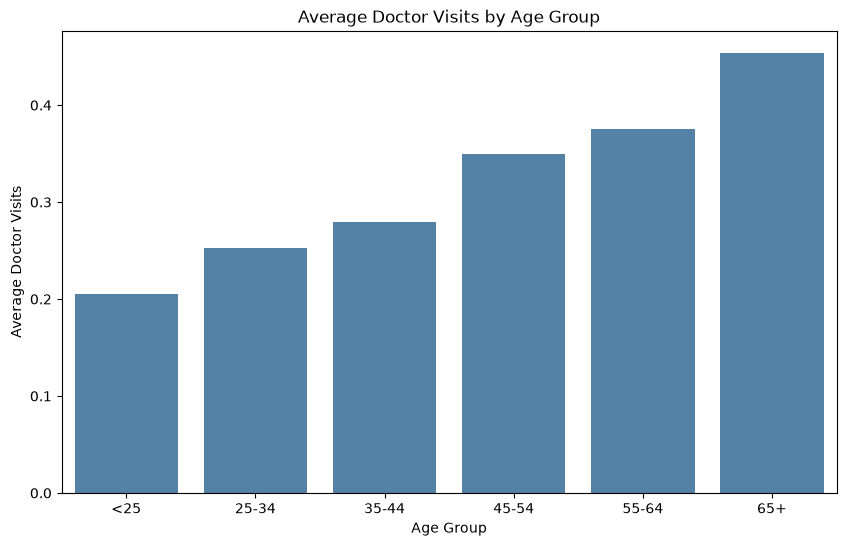

In [9]:
# Convert scaled age back to years
df["age_years"] = (df["age"] * 100).round().astype(int)
print(df["age_years"].describe())

# Age groups
bins = [0, 24, 34, 44, 54, 64, 100]
labels = ["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
df["age_group"] = pd.cut(df["age_years"], bins=bins, labels=labels)

age_analysis = df.groupby("age_group", observed=False)["visits"].agg(["count", "mean", "median"]).round(3)
print(age_analysis)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="age_group", y="visits", estimator="mean", errorbar=None, color="steelblue")

plt.title("Average Doctor Visits by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Doctor Visits")
plt.show()

         count   mean  median
illness                      
0         1554  0.079     0.0
1         1638  0.295     0.0
2          946  0.404     0.0
3          542  0.421     0.0
4          274  0.577     0.0
5          236  0.814     0.0


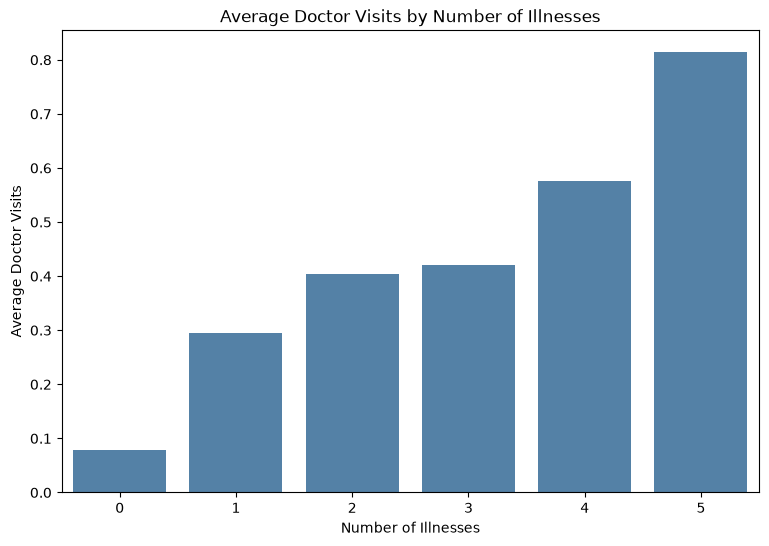

In [10]:
illness_analysis = df.groupby("illness")["visits"].agg(["count", "mean", "median"]).round(3)
print(illness_analysis)

plt.figure(figsize=(9, 6))
sns.barplot(data=df, x="illness", y="visits", estimator="mean", errorbar=None, color="steelblue")

plt.title("Average Doctor Visits by Number of Illnesses")
plt.xlabel("Number of Illnesses")
plt.ylabel("Average Doctor Visits")
plt.show()

        count   mean  median
health                      
0        3026  0.199     0.0
1         823  0.335     0.0
2         446  0.381     0.0
3         273  0.418     0.0
4         187  0.535     0.0
5         132  0.530     0.0
6         104  0.625     0.0
7          61  0.918     0.0
8          42  0.476     0.0
9          32  0.656     0.0
10         21  1.524     1.0
11         24  0.833     1.0
12         19  1.000     1.0


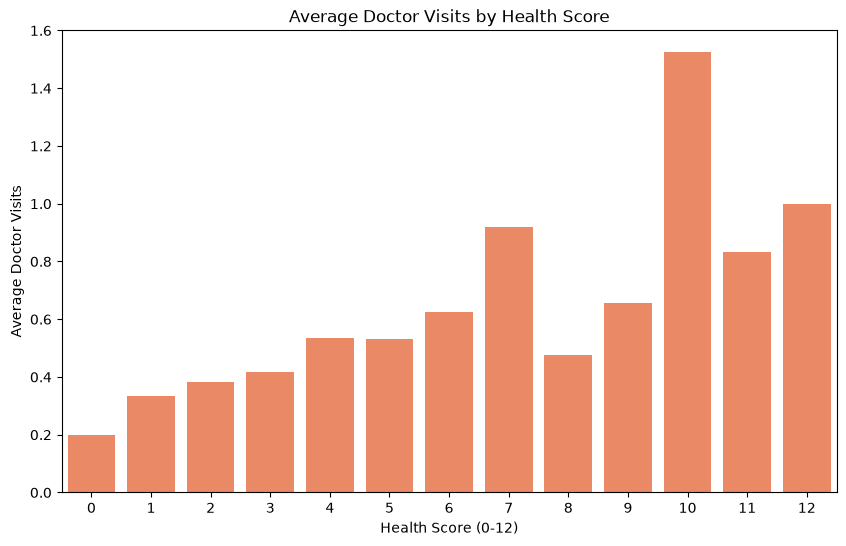

In [11]:
health_analysis = df.groupby("health")["visits"].agg(["count", "mean", "median"]).round(3)
print(health_analysis)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="health", y="visits", estimator="mean", errorbar=None, color="coral")

plt.title("Average Doctor Visits by Health Score")
plt.xlabel("Health Score (0-12)")
plt.ylabel("Average Doctor Visits")
plt.show()

count    5190.00
mean        0.86
std         2.89
min         0.00
25%         0.00
50%         0.00
75%         0.00
max        14.00
Name: reduced, dtype: float64
               count   mean
reduced_group              
0 days          4454  0.184
1-3              359  0.574
4-7              140  1.086
8-14             237  1.641


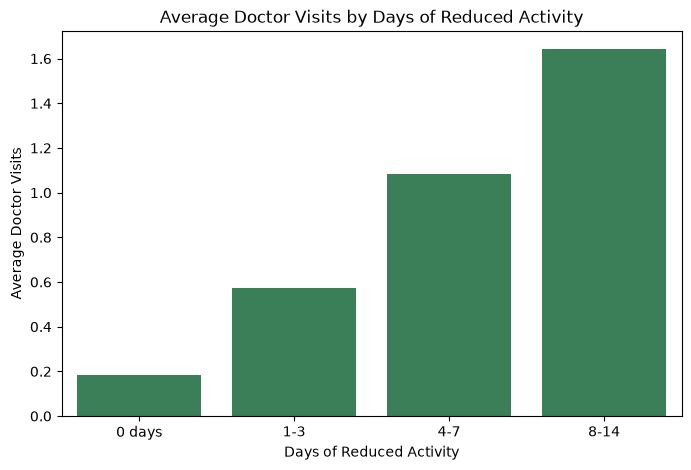


Correlation with visits: 0.419


In [12]:
print(df["reduced"].describe().round(2))

# Group days into buckets for a clearer chart
df["reduced_group"] = pd.cut(df["reduced"], bins=[-1, 0, 3, 7, 14], labels=["0 days", "1-3", "4-7", "8-14"])

reduced_analysis = df.groupby("reduced_group", observed=False)["visits"].agg(["count", "mean"]).round(3)
print(reduced_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="reduced_group", y="visits", estimator="mean", errorbar=None, color="seagreen")

plt.title("Average Doctor Visits by Days of Reduced Activity")
plt.xlabel("Days of Reduced Activity")
plt.ylabel("Average Doctor Visits")
plt.show()

print("\nCorrelation with visits:", round(df["reduced"].corr(df["visits"]), 3))

          count   mean  median
nchronic                      
no         3098  0.272     0.0
yes        2092  0.346     0.0

          count   mean  median
lchronic                      
no         4585  0.262     0.0
yes         605  0.603     0.0

                            count   mean
chronic_status                         
Chronic (limits activity)    605  0.603
Chronic (no limit)          2092  0.346
No chronic condition        2493  0.192


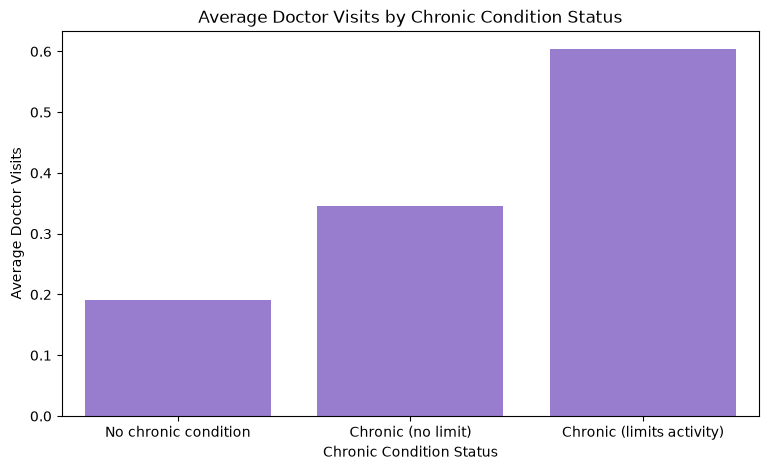

In [13]:
print(df.groupby("nchronic")["visits"].agg(["count", "mean", "median"]).round(3))
print()
print(df.groupby("lchronic")["visits"].agg(["count", "mean", "median"]).round(3))

# Combine into one chronic status
def chronic_status(row):
    if row["lchronic"] == "yes":
        return "Chronic (limits activity)"
    elif row["nchronic"] == "yes":
        return "Chronic (no limit)"
    return "No chronic condition"

df["chronic_status"] = df.apply(chronic_status, axis=1)

chronic_analysis = df.groupby("chronic_status")["visits"].agg(["count", "mean"]).round(3)
print("\n", chronic_analysis)

plt.figure(figsize=(9, 5))
order = ["No chronic condition", "Chronic (no limit)", "Chronic (limits activity)"]
sns.barplot(data=df, x="chronic_status", y="visits", order=order, estimator="mean", errorbar=None, color="mediumpurple")

plt.title("Average Doctor Visits by Chronic Condition Status")
plt.xlabel("Chronic Condition Status")
plt.ylabel("Average Doctor Visits")
plt.show()

count    5190.000
mean        0.583
std         0.369
min         0.000
25%         0.250
50%         0.550
75%         0.900
max         1.500
Name: income, dtype: float64
IntervalIndex([(-0.001, 0.25], (0.25, 0.55], (0.55, 0.9], (0.9, 1.5]], dtype='interval[float64, right]')
                count   mean  median
income_group                        
(-0.001, 0.25]   1638  0.398     0.0
(0.25, 0.55]     1329  0.305     0.0
(0.55, 0.9]      1485  0.230     0.0
(0.9, 1.5]        738  0.225     0.0


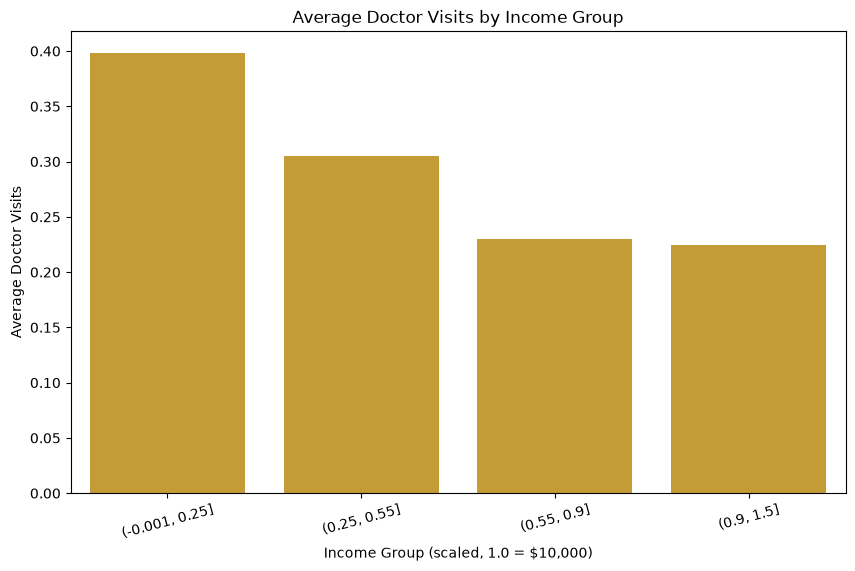

In [14]:
print(df["income"].describe().round(3))

df["income_group"] = pd.qcut(df["income"], q=4, duplicates="drop")
print(df["income_group"].cat.categories)   # check the 4 income bands

income_analysis = df.groupby("income_group", observed=False)["visits"].agg(["count", "mean", "median"]).round(3)
print(income_analysis)

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="income_group", y="visits", estimator="mean", errorbar=None, color="goldenrod")

plt.title("Average Doctor Visits by Income Group")
plt.xlabel("Income Group (scaled, 1.0 = $10,000)")
plt.ylabel("Average Doctor Visits")
plt.xticks(rotation=15)
plt.show()

--- private ---
         count   mean  median
private                      
no        2892  0.307     0.0
yes       2298  0.295     0.0

--- freepoor ---
          count   mean  median
freepoor                      
no         4968  0.308     0.0
yes         222  0.158     0.0

--- freerepat ---
           count   mean  median
freerepat                      
no          4099  0.258     0.0
yes         1091  0.467     0.0

                     count   mean
coverage_type                    
Free (low income)      222  0.158
Free (repatriation)   1091  0.467
No extra coverage     1579  0.218
Private               2298  0.295


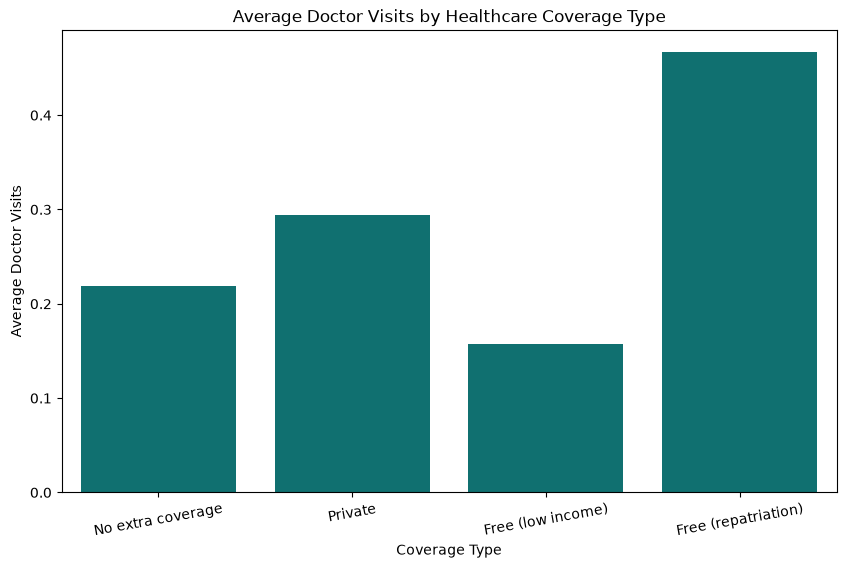

In [15]:
for col in ["private", "freepoor", "freerepat"]:
    print(f"--- {col} ---")
    print(df.groupby(col)["visits"].agg(["count", "mean", "median"]).round(3))
    print()

# Combine into one coverage type
def coverage(row):
    if row["private"] == "yes":
        return "Private"
    elif row["freepoor"] == "yes":
        return "Free (low income)"
    elif row["freerepat"] == "yes":
        return "Free (repatriation)"
    return "No extra coverage"

df["coverage_type"] = df.apply(coverage, axis=1)

coverage_analysis = df.groupby("coverage_type")["visits"].agg(["count", "mean"]).round(3)
print(coverage_analysis)

plt.figure(figsize=(10, 6))
order = ["No extra coverage", "Private", "Free (low income)", "Free (repatriation)"]
sns.barplot(data=df, x="coverage_type", y="visits", order=order, estimator="mean", errorbar=None, color="teal")

plt.title("Average Doctor Visits by Healthcare Coverage Type")
plt.xlabel("Coverage Type")
plt.ylabel("Average Doctor Visits")
plt.xticks(rotation=10)
plt.show()

           visits  age_years  income  illness  reduced  health
visits       1.00       0.12   -0.08     0.22     0.42    0.19
age_years    0.12       1.00   -0.27     0.20     0.09    0.02
income      -0.08      -0.27    1.00    -0.15    -0.05   -0.09
illness      0.22       0.20   -0.15     1.00     0.22    0.36
reduced      0.42       0.09   -0.05     0.22     1.00    0.28
health       0.19       0.02   -0.09     0.36     0.28    1.00


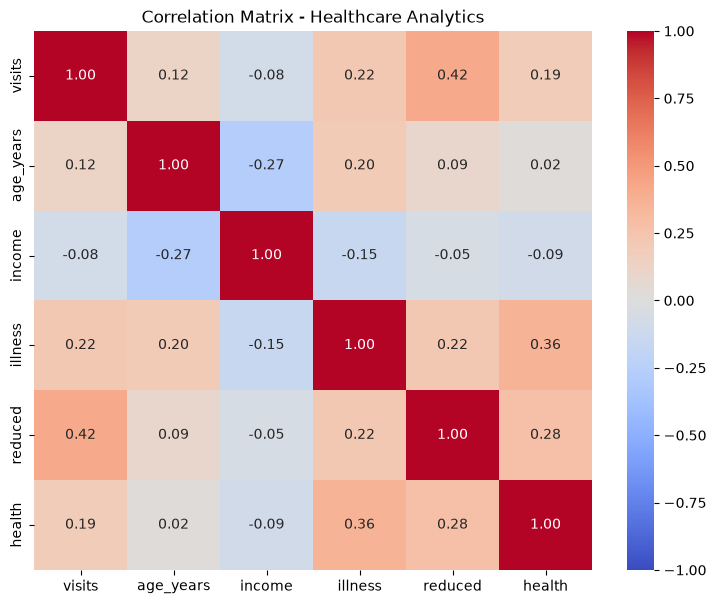


Correlation with visits (strongest first):
reduced      0.42
illness      0.22
health       0.19
age_years    0.12
income      -0.08
Name: visits, dtype: float64


In [16]:
numeric_cols = ["visits", "age_years", "income", "illness", "reduced", "health"]
corr = df[numeric_cols].corr().round(2)
print(corr)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix - Healthcare Analytics")
plt.show()

print("\nCorrelation with visits (strongest first):")
print(corr["visits"].drop("visits").sort_values(ascending=False))

In [17]:
print("=" * 50)
print("KEY FINDINGS - HEALTHCARE ANALYTICS")
print("=" * 50)

total = len(df)
zero_pct = (df["visits"] == 0).mean() * 100
print(f"1. Total records: {total:,}")
print(f"2. Average visits: {df['visits'].mean():.2f} | Max visits: {df['visits'].max()}")
print(f"3. {zero_pct:.1f}% of people had zero doctor visits")

g = df.groupby("gender")["visits"].mean()
print(f"4. Average visits - Female: {g['female']:.2f}, Male: {g['male']:.2f}")

a = df.groupby("age_group", observed=False)["visits"].mean()
print(f"5. Youngest group ({a.index[0]}): {a.iloc[0]:.2f} | Oldest group ({a.index[-1]}): {a.iloc[-1]:.2f}")

i = df.groupby("illness")["visits"].mean()
print(f"6. 0 illnesses: {i.iloc[0]:.2f} visits | 5 illnesses: {i.iloc[-1]:.2f} visits")

c = df.groupby("chronic_status")["visits"].mean()
print(f"7. No chronic condition: {c['No chronic condition']:.2f} | Chronic limiting activity: {c['Chronic (limits activity)']:.2f}")

cov = df.groupby("coverage_type")["visits"].mean().sort_values(ascending=False)
print(f"8. Highest visits by coverage: {cov.index[0]} ({cov.iloc[0]:.2f})")

vc = df[["visits", "age_years", "income", "illness", "reduced", "health"]].corr()["visits"].drop("visits")
print(f"9. Strongest correlation with visits: {vc.idxmax()} (r = {vc.max():.2f})")
print(f"10. Income correlation with visits: r = {vc['income']:.2f} (slightly negative)")

KEY FINDINGS - HEALTHCARE ANALYTICS
1. Total records: 5,190
2. Average visits: 0.30 | Max visits: 9
3. 79.8% of people had zero doctor visits
4. Average visits - Female: 0.36, Male: 0.24
5. Youngest group (<25): 0.21 | Oldest group (65+): 0.45
6. 0 illnesses: 0.08 visits | 5 illnesses: 0.81 visits
7. No chronic condition: 0.19 | Chronic limiting activity: 0.60
8. Highest visits by coverage: Free (repatriation) (0.47)
9. Strongest correlation with visits: reduced (r = 0.42)
10. Income correlation with visits: r = -0.08 (slightly negative)
